# Image classification with a neural network

In [1]:
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
from PIL import Image

## Select an image and classify it

In [2]:
# Load pretrained model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval();

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]


In [3]:
# Preprocessing transformations
preprocess = models.ResNet18_Weights.DEFAULT.transforms()

In [8]:
# Load and preprocess image
# Select image from images/ directory
img = Image.open('summer_school_2026/ml/images/image_2.jpeg').convert('RGB')
input_tensor = preprocess(img).unsqueeze(0)  # shape: [1, 3, 224, 224]

In [9]:
# Get model predictions
with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.softmax(logits, dim=1)

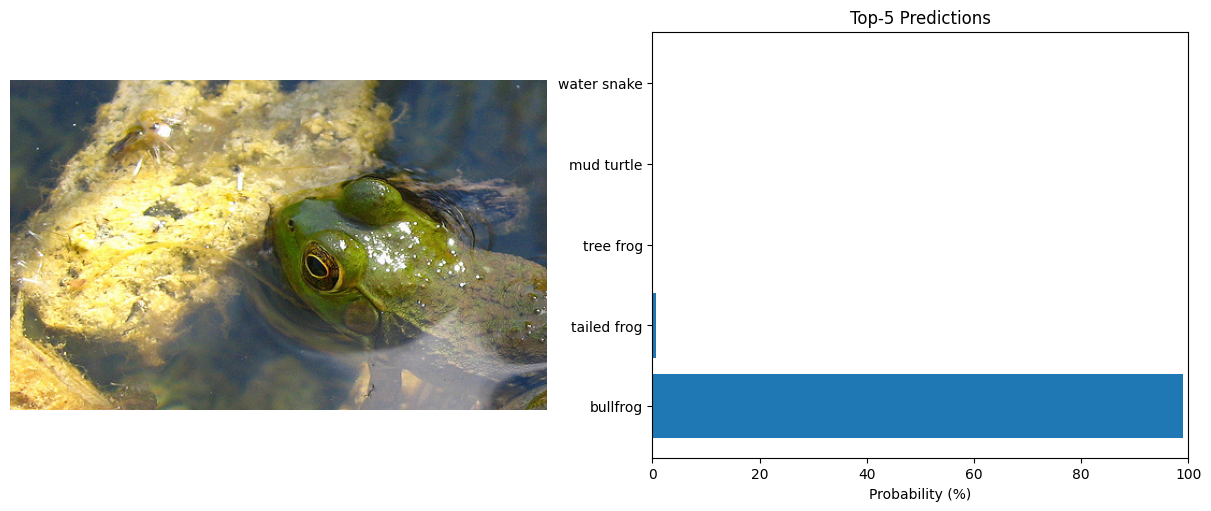

In [10]:
# Get top-5 predictions
top5_prob, top5_catid = torch.topk(probs[0], k=5)
categories = models.ResNet18_Weights.DEFAULT.meta['categories']

# Convert predictions to categories and scores
labels = [categories[c.item()] for c in top5_catid]
scores = [p.item() * 100 for p in top5_prob]

# Visualize results
fig, (ax1, ax2) = plt.subplots(ncols=2, layout='constrained', figsize=[12, 5])

# Visualize image
ax1.imshow(img)
ax1.axis("off")

# Visualize predictions
ax2.barh(labels, scores)
ax2.set_xlabel("Probability (%)")
ax2.set_title("Top-5 Predictions")
ax2.set_xlim(0, 100);